In [32]:
!pip install kagglehub[pandas-datasets]
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\muratkokludataset\dry-bean-dataset\versions\1


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [34]:
nested_path = f"{path}/Dry_Bean_Dataset"
print("Files inside Dry_Bean_Dataset folder:")
print(os.listdir(nested_path))

Files inside Dry_Bean_Dataset folder:
['Dry_Bean_Dataset.arff', 'Dry_Bean_Dataset.xlsx', 'Dry_Bean_Dataset_Citation_Request.txt']


In [35]:
!pip install openpyxl

file_path = f"{path}/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx"
df = pd.read_excel(file_path)

print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [36]:
print("Missing values count per column:\n", df.isnull().sum().sum())

Missing values count per column:
 0


In [37]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [39]:
print("Class Frequencies:")
print(df['Class'].value_counts())

Class Frequencies:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17352\3544482538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


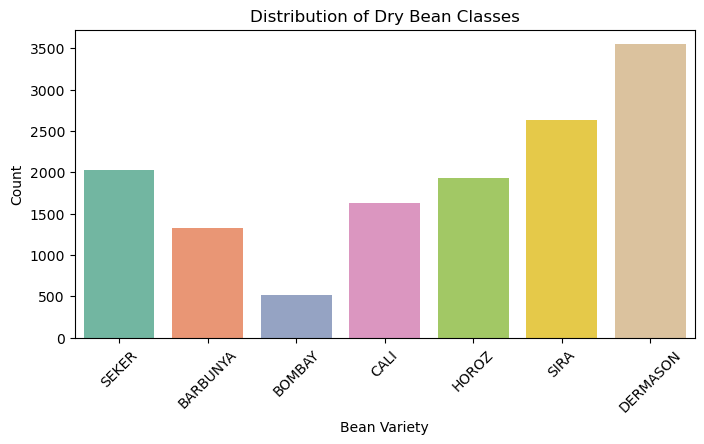

In [40]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Class', palette='Set2')
plt.title('Distribution of Dry Bean Classes')
plt.xlabel('Bean Variety')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [41]:
print(df.shape)
df

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [42]:
X = df.drop(columns=['Class'])
y_raw = df['Class']

In [43]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform ONLY test set to avoid leakage!

print(f"Training set: {X_train_scaled.shape} and Testing set: {X_test_scaled.shape}")

Training set: (10888, 16) and Testing set: (2723, 16)


In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []

print("training svm kernels")
for kernel in kernels:
    
    start_time = time.time()
    
    #instantiating & training model
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    # predict
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    kernel_results.append({
        'Kernel': kernel,
        'Training_Time_Sec': round(training_time, 4),
        'Accuracy': round(acc, 4),
        'Weighted_F1': round(f1, 4)
    })
    
    print(f"Kernel: {kernel:8s} | Training Time: {training_time:6.2f}s | Accuracy: {acc:.4f} | F1: {f1:.4f}")

# converting to DataFrame
kernel_df = pd.DataFrame(kernel_results)

training svm kernels
Kernel: linear   | Training Time:   0.35s | Accuracy: 0.9221 | F1: 0.9221
Kernel: poly     | Training Time:   0.45s | Accuracy: 0.9144 | F1: 0.9159
Kernel: rbf      | Training Time:   0.38s | Accuracy: 0.9221 | F1: 0.9222
Kernel: sigmoid  | Training Time:   0.55s | Accuracy: 0.7293 | F1: 0.7430


In [46]:
c_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.1]
degrees = [2, 3, 4] 

grid_results = []

# tuning RBF & linear kernels
for kernel in ['linear', 'rbf']:
    for c in c_values:
        for gamma in (gamma_values if kernel == 'rbf' else ['scale']):
            svm = SVC(kernel=kernel, C=c, gamma=gamma, random_state=42)
            svm.fit(X_train_scaled, y_train)
            
            y_pred = svm.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted')
            rec = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')
            
            grid_results.append({
                'Kernel': kernel,
                'C': c,
                'Gamma': str(gamma),
                'Degree': 'N/A',
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1_Score': f1
            })

# tuning polynomial kernel with degree
for c in c_values:
    for deg in degrees:
        svm = SVC(kernel='poly', C=c, degree=deg, random_state=42)
        svm.fit(X_train_scaled, y_train)
        
        y_pred = svm.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        grid_results.append({
            'Kernel': 'poly',
            'C': c,
            'Gamma': 'scale',
            'Degree': deg,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1_Score': f1
        })

# storing into dataframe
grid_df = pd.DataFrame(grid_results)

print("Top Configurations by Weighted F1-Score:")
grid_df.sort_values(by='F1_Score', ascending=False).head(10)

Top Configurations by Weighted F1-Score:


,Kernel,C,Gamma,Degree,Accuracy,Precision,Recall,F1_Score
11,rbf,10.0,0.1,N/A,0.927286,0.927227,0.927286,0.927198
8,rbf,1.0,0.1,N/A,0.924715,0.924877,0.924715,0.924713
9,rbf,10.0,scale,N/A,0.924348,0.924320,0.924348,0.924295
0,linear,0.1,scale,N/A,0.922879,0.923186,0.922879,0.922914
10,rbf,10.0,0.01,N/A,0.922879,0.923017,0.922879,0.922896
2,linear,10.0,scale,N/A,0.922145,0.922386,0.922145,0.922205
6,rbf,1.0,scale,N/A,0.922145,0.922426,0.922145,0.922177
1,linear,1.0,scale,N/A,0.922145,0.922227,0.922145,0.922107
18,poly,10.0,scale,2,0.921410,0.922745,0.921410,0.921806
5,rbf,0.1,0.1,N/A,0.921410,0.922428,0.921410,0.921532


In [52]:
best_svm = grid_df.loc[grid_df['F1_Score'].idxmax()]

print("BEST SVM MODEL CONFIGURATION")
print(f"Optimal Kernel  : {best_svm['Kernel']}")
print(f"Optimal C       : {best_svm['C']}")
print(f"Optimal Gamma   : {best_svm['Gamma']}")
print(f"Optimal Degree  : {best_svm['Degree']}")
print(f"Best Accuracy   : {best_svm['Accuracy']:.4f}")
print(f"Best Precision  : {best_svm['Precision']:.4f}")
print(f"Best Recall     : {best_svm['Recall']:.4f}")
print(f"Best F1-Score   : {best_svm['F1_Score']:.4f}")

BEST SVM MODEL CONFIGURATION
Optimal Kernel  : rbf
Optimal C       : 10.0
Optimal Gamma   : 0.1
Optimal Degree  : N/A
Best Accuracy   : 0.9273
Best Precision  : 0.9272
Best Recall     : 0.9273
Best F1-Score   : 0.9272


In [49]:
raw_gamma = best_svm['Gamma']
if isinstance(raw_gamma, str) and raw_gamma not in ['scale', 'auto']:
    gamma_val = float(raw_gamma)
else:
    gamma_val = raw_gamma

raw_degree = best_svm['Degree']
degree_val = int(raw_degree) if raw_degree != 'N/A' else 3

In [50]:
final_svm = SVC(
    kernel=best_svm['Kernel'], 
    C=float(best_svm['C']), 
    gamma=gamma_val,
    degree=degree_val,
    random_state=42
)

final_svm.fit(X_train_scaled, y_train)
y_pred_final = final_svm.predict(X_test_scaled)

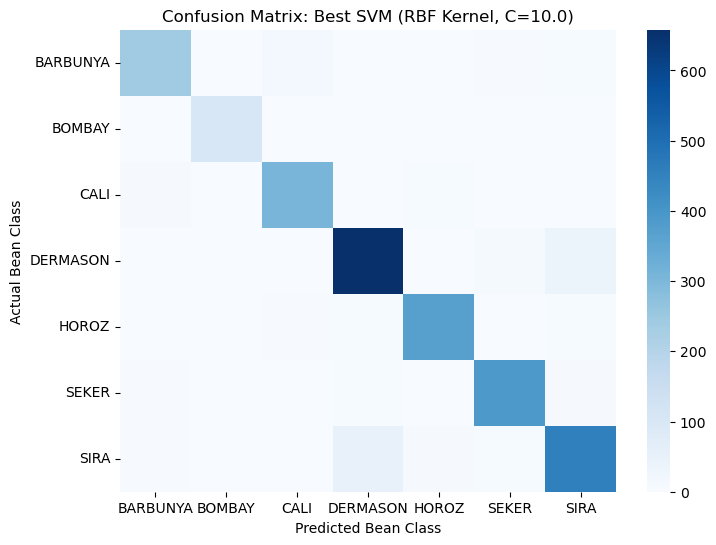

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=False, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix: Best SVM ")
plt.xlabel("Predicted Bean Class")
plt.ylabel("Actual Bean Class")
plt.show()